In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [3]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

cuda
NVIDIA GeForce RTX 4070 Laptop GPU


In [4]:
BATCH_SIZE = 128
LEARNING_RATE = 1e-3
EPOCHS = 10

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

100.0%
100.0%
100.0%
100.0%


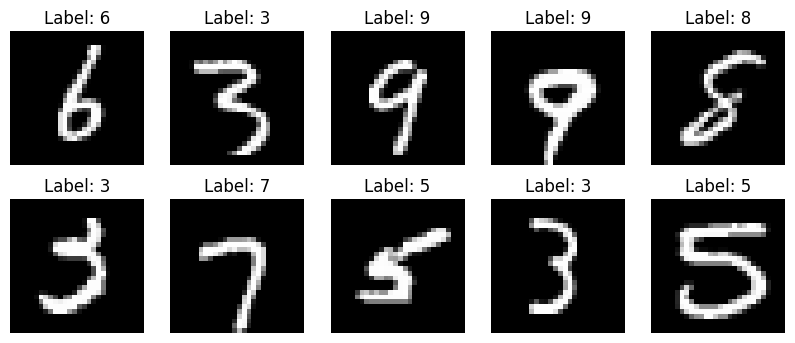

In [6]:
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze(), cmap="gray")
    ax.set_title(f"Label: {labels[i].item()}")
    ax.axis("off")

plt.show()

In [7]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(784, 1024),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(1024, 1024),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(1024, 10)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.network(x)


model = MLP().to(device)
print(model)

MLP(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=1024, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=1024, out_features=1024, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=1024, out_features=10, bias=True)
  )
)


In [8]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

In [9]:
train_losses = []
train_accuracies = []

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = total_loss / len(train_loader)
    epoch_acc = 100 * correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {epoch_acc:.2f}%"
    )

Epoch [1/10] Loss: 0.2165 Accuracy: 93.43%
Epoch [2/10] Loss: 0.1022 Accuracy: 96.88%
Epoch [3/10] Loss: 0.0786 Accuracy: 97.55%
Epoch [4/10] Loss: 0.0614 Accuracy: 98.05%
Epoch [5/10] Loss: 0.0560 Accuracy: 98.19%
Epoch [6/10] Loss: 0.0457 Accuracy: 98.55%
Epoch [7/10] Loss: 0.0416 Accuracy: 98.67%
Epoch [8/10] Loss: 0.0438 Accuracy: 98.60%
Epoch [9/10] Loss: 0.0345 Accuracy: 98.92%
Epoch [10/10] Loss: 0.0354 Accuracy: 98.86%


In [10]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 98.14%


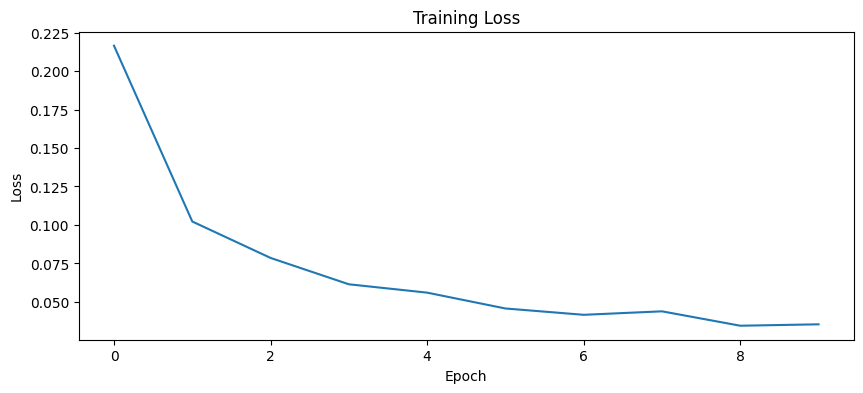

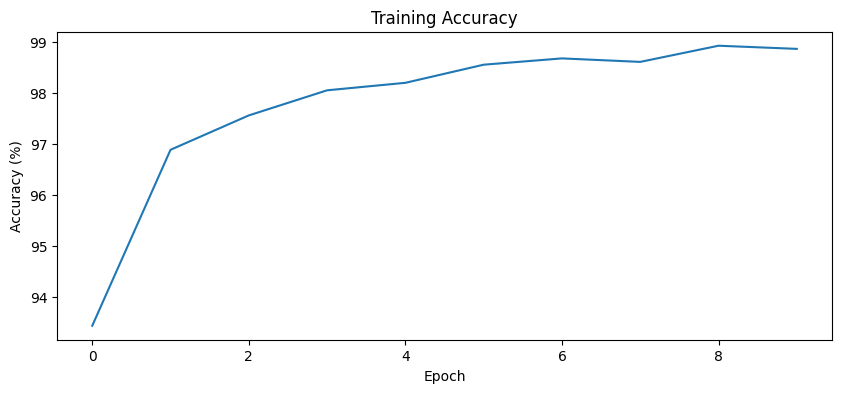

In [11]:
plt.figure(figsize=(10, 4))

plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.figure(figsize=(10, 4))

plt.plot(train_accuracies)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.show()